# WTI MM Trend/Residual Decomposition — Lead/Lag with Price

Decompose MM net positioning into:

- **MM-TREND**: the component explained by prior 1-week price return
  (the trend-following part)
- **MM-RESIDUAL**: what's left after removing the trend-following
  component (flows, risk limits, cross-asset, fund inflows, etc.)

Key test: does the residual predict future price?

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from sklearn.linear_model import LinearRegression

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load COT + prices

In [2]:
COT_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'

raw = pd.read_csv(COT_PATH, low_memory=False)
WTI_CODES = ['067651', '067411']
wti_raw = raw[raw['cftc_contract_market_code'].isin(WTI_CODES)].copy()
wti_raw['as_of_date'] = pd.to_datetime(wti_raw['report_date_as_yyyy_mm_dd'])

_SUM_COLS = ['open_interest_all',
             'm_money_positions_long_all', 'm_money_positions_short_all']
for c in _SUM_COLS:
    wti_raw[c] = pd.to_numeric(wti_raw[c], errors='coerce')

wti = wti_raw.groupby('as_of_date')[_SUM_COLS].sum().reset_index()
days_ahead = (4 - wti['as_of_date'].dt.dayofweek) % 7
wti['release_date'] = wti['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
wti['mm_net'] = wti['m_money_positions_long_all'] - wti['m_money_positions_short_all']
wti.sort_values('as_of_date', inplace=True)
wti.reset_index(drop=True, inplace=True)

prices = pd.read_csv('../../../../cache/preprocessed_data/wti_prices_panel.csv',
                      usecols=['tradeDate', 'F1_RolledPrice'])
prices['tradeDate'] = pd.to_datetime(prices['tradeDate'])
prices.sort_values('tradeDate', inplace=True)

# Join prices on as_of_date (Tuesday), not release_date (Friday),
# to match the paper's P&L convention: position(Tue) * price_change(Tue-to-Tue)
wti = pd.merge_asof(
    wti.sort_values('as_of_date'),
    prices.rename(columns={'tradeDate': 'as_of_date'}),
    on='as_of_date', direction='backward', tolerance=pd.Timedelta(days=3),
)
wti.dropna(subset=['mm_net', 'F1_RolledPrice'], inplace=True)
wti.sort_values('as_of_date', inplace=True)
wti.reset_index(drop=True, inplace=True)

# Weekly changes and prior 1w price return
wti['mm_net_chg'] = wti['mm_net'].diff()
wti['price_ret'] = wti['F1_RolledPrice'].pct_change() * 100
wti['prior_1w_price_ret'] = wti['price_ret'].shift(1)

print(f'Rows: {len(wti)}')
print(f'Range: {wti["as_of_date"].min().date()} -> {wti["as_of_date"].max().date()}')

Rows: 813
Range: 2010-01-05 -> 2025-08-05


## 2. Rolling regression: MM net change ~ prior 1w price return

Expanding window (no lookahead): at each week t, regress on all
data up to t-1, then predict at t.

In [3]:
MIN_TRAIN = 52  # 1 year warmup

mm_chg = wti['mm_net_chg'].values
prior_ret = wti['prior_1w_price_ret'].values

mm_trend = np.full(len(wti), np.nan)
mm_residual = np.full(len(wti), np.nan)
betas = np.full(len(wti), np.nan)

for t in range(MIN_TRAIN, len(wti)):
    # Train on [0:t], predict at t
    X_train = prior_ret[:t].reshape(-1, 1)
    y_train = mm_chg[:t]
    mask = ~(np.isnan(X_train.flatten()) | np.isnan(y_train))
    if mask.sum() < 20:
        continue
    reg = LinearRegression().fit(X_train[mask], y_train[mask])
    
    x_t = prior_ret[t]
    if np.isnan(x_t):
        continue
    
    pred = reg.predict([[x_t]])[0]
    mm_trend[t] = pred
    mm_residual[t] = mm_chg[t] - pred
    betas[t] = reg.coef_[0]

wti['mm_trend'] = mm_trend
wti['mm_residual'] = mm_residual
wti['beta'] = betas

df = wti.dropna(subset=['mm_trend', 'mm_residual', 'price_ret']).reset_index(drop=True)

print(f'Clean rows: {len(df)}')
print(f'\nRegression: mm_net_chg ~ prior_1w_price_ret (expanding window)')
print(f'  Final beta: {df["beta"].iloc[-1]:+.0f} contracts per 1% price return')
print(f'  Beta range: [{df["beta"].min():+.0f}, {df["beta"].max():+.0f}]')
print(f'\nVariance decomposition:')
var_total = df['mm_net_chg'].var()
var_trend = df['mm_trend'].var()
var_resid = df['mm_residual'].var()
print(f'  Var(total):    {var_total:14,.0f}')
print(f'  Var(trend):    {var_trend:14,.0f}  ({var_trend/var_total*100:.1f}%)')
print(f'  Var(residual): {var_resid:14,.0f}  ({var_resid/var_total*100:.1f}%)')

Clean rows: 761

Regression: mm_net_chg ~ prior_1w_price_ret (expanding window)
  Final beta: +6 contracts per 1% price return
  Beta range: [-24, +1371]

Variance decomposition:
  Var(total):       676,981,111
  Var(trend):       171,547,074  (25.3%)
  Var(residual):    861,418,881  (127.2%)


## 3. Visualise decomposition

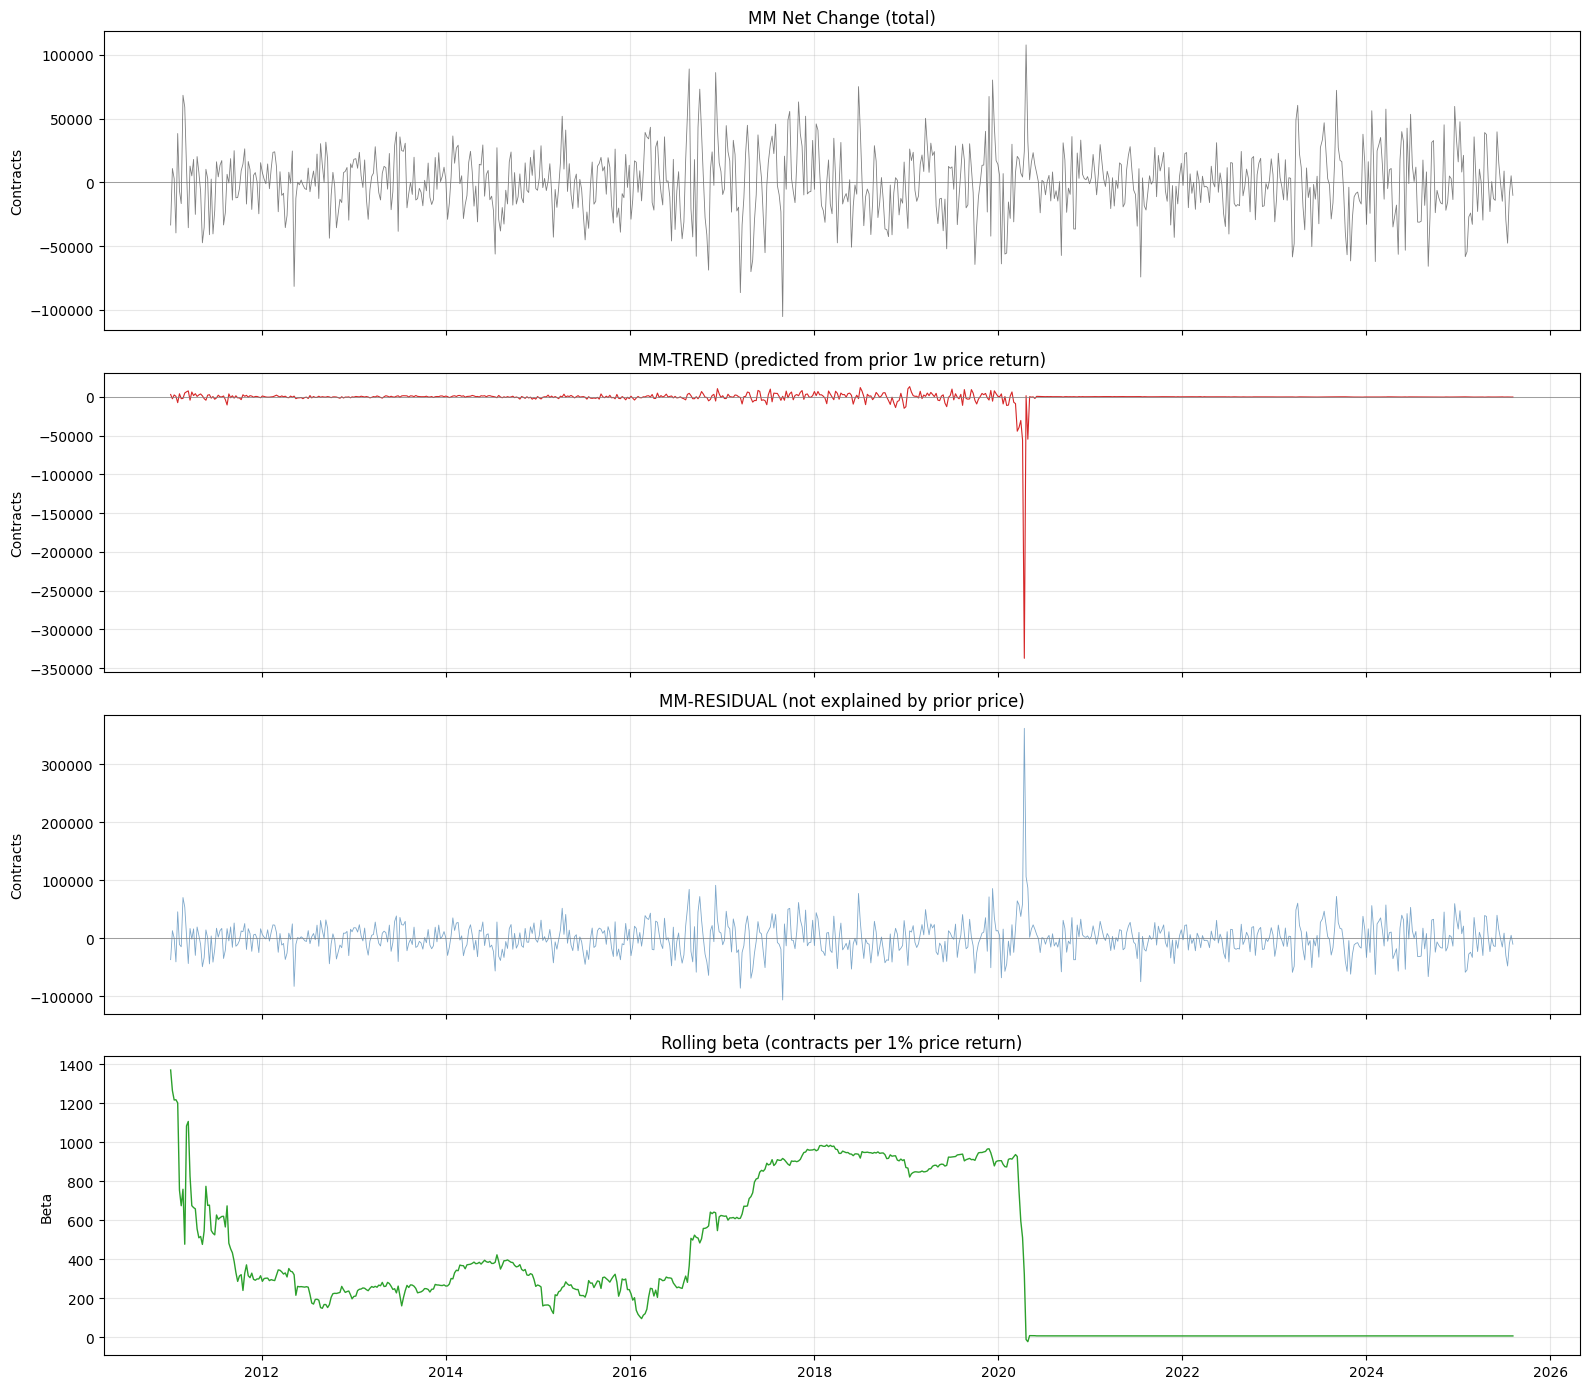

In [4]:
dt = pd.to_datetime(df['as_of_date'])

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

ax = axes[0]
ax.plot(dt, df['mm_net_chg'], color='black', lw=0.6, alpha=0.5)
ax.set_ylabel('Contracts')
ax.set_title('WTI MM Net Change (total)')
ax.axhline(0, color='grey', lw=0.5)

ax = axes[1]
ax.plot(dt, df['mm_trend'], color='tab:red', lw=0.8)
ax.set_ylabel('Contracts')
ax.set_title('WTI MM-TREND (predicted from prior 1w price return)')
ax.axhline(0, color='grey', lw=0.5)

ax = axes[2]
ax.plot(dt, df['mm_residual'], color='steelblue', lw=0.6, alpha=0.7)
ax.set_ylabel('Contracts')
ax.set_title('WTI MM-RESIDUAL (not explained by prior price)')
ax.axhline(0, color='grey', lw=0.5)

ax = axes[3]
ax.plot(dt, df['beta'], color='tab:green', lw=1)
ax.set_ylabel('Beta')
ax.set_title('WTI Rolling beta (contracts per 1% price return)')

plt.tight_layout()
plt.show()

## 4. Contemporaneous correlation

In [5]:
print('Same-week Spearman: component vs price return')
for label, col in [('MM Net change (total)', 'mm_net_chg'),
                    ('MM-TREND',              'mm_trend'),
                    ('MM-RESIDUAL',           'mm_residual')]:
    rho, p = sp_stats.spearmanr(df[col], df['price_ret'])
    print(f'  {label:30s}  rho = {rho:+.3f}  (p = {p:.1e})')

Same-week Spearman: component vs price return
  MM Net change (total)           rho = +0.613  (p = 9.5e-80)
  MM-TREND                        rho = +0.040  (p = 2.7e-01)
  MM-RESIDUAL                     rho = +0.601  (p = 7.4e-76)


## 5. CCF: MM-TREND change vs price

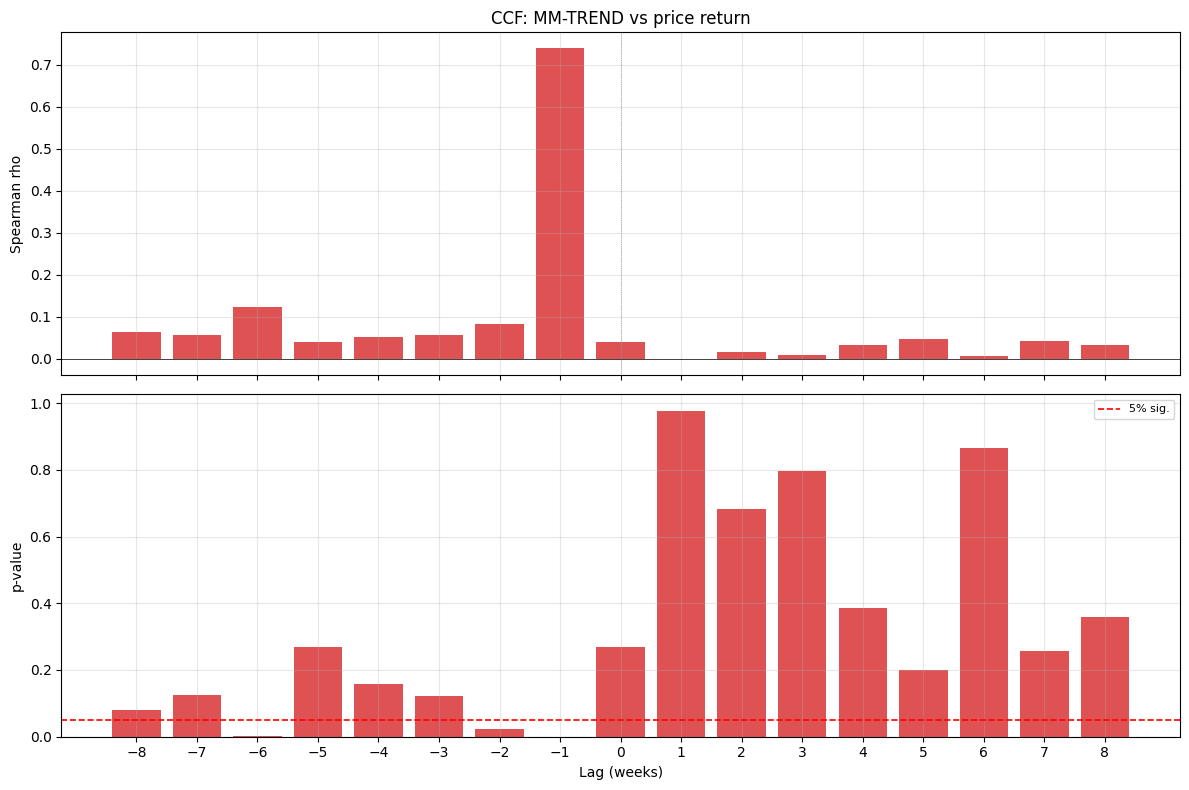

 Lag       rho       p-val
----------------------------
  -8   +0.064       8.0e-02
  -7   +0.056       1.2e-01
  -6   +0.122 *     8.0e-04
  -5   +0.040       2.7e-01
  -4   +0.051       1.6e-01
  -3   +0.056       1.2e-01
  -2   +0.083 *     2.2e-02
  -1   +0.740 *    7.3e-133
   0   +0.040       2.7e-01
   1   -0.001       9.8e-01
   2   +0.015       6.8e-01
   3   +0.009       8.0e-01
   4   +0.032       3.9e-01
   5   +0.047       2.0e-01
   6   +0.006       8.6e-01
   7   +0.041       2.6e-01
   8   +0.033       3.6e-01


In [6]:
MAX_LAG = 8

def compute_ccf(x, y, max_lag):
    lags = range(-max_lag, max_lag + 1)
    rhos, pvals = [], []
    for k in lags:
        if k >= 0:
            rho, p = sp_stats.spearmanr(x[:len(x)-k], y[k:])
        else:
            rho, p = sp_stats.spearmanr(x[-k:], y[:len(y)+k])
        rhos.append(rho)
        pvals.append(p)
    return list(lags), rhos, pvals

trend_vals = df['mm_trend'].values
resid_vals = df['mm_residual'].values
net_vals = df['mm_net_chg'].values
price_vals = df['price_ret'].values

lags, rhos_trend, pvals_trend = compute_ccf(trend_vals, price_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.bar(lags, rhos_trend, color='tab:red', alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('CCF: WTI MM-TREND vs price return')

ax = axes[1]
ax.bar(lags, pvals_trend, color='tab:red', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)')
ax.set_xticks(lags)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"rho":>8s}  {"p-val":>10s}')
print('-' * 28)
for k, r, p in zip(lags, rhos_trend, pvals_trend):
    s = '*' if p < 0.05 else ' '
    print(f'{k:>4d}  {r:>+7.3f} {s}  {p:>10.1e}')

## 6. CCF: MM-RESIDUAL vs price

This is the key test: does the non-trend-following component
of positioning predict future price?

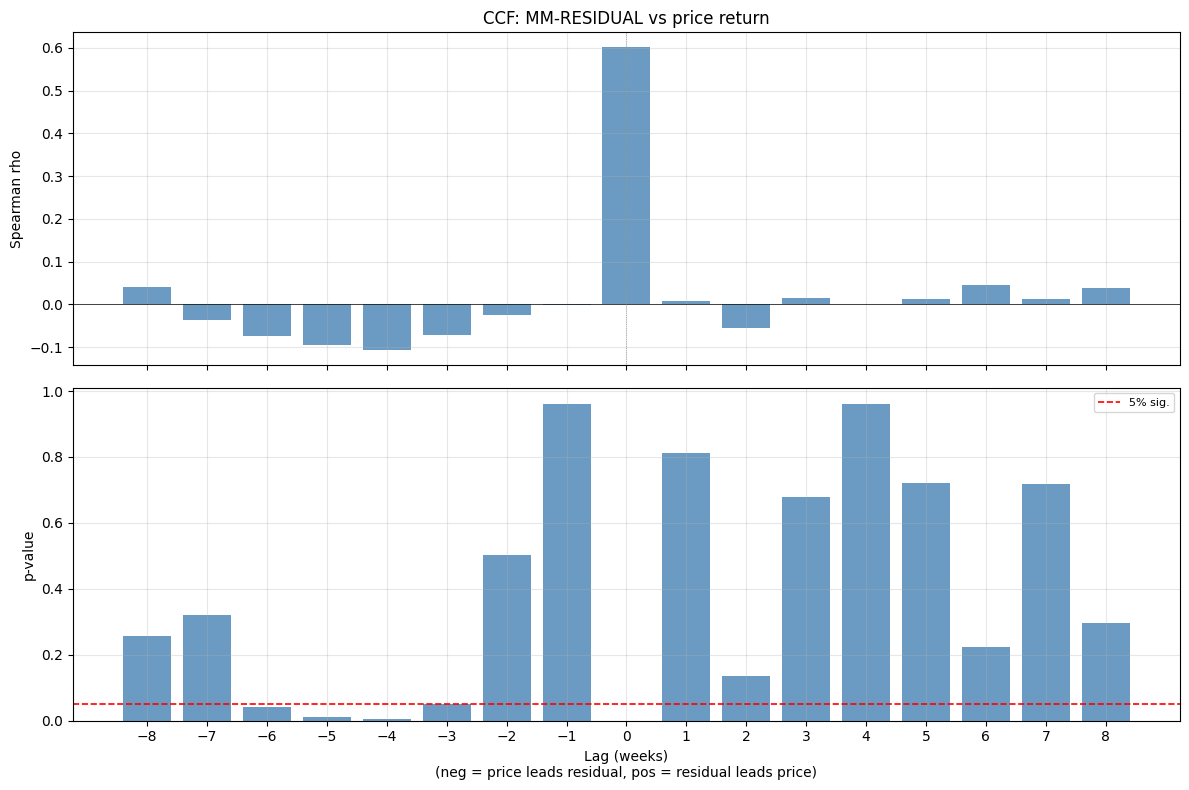

 Lag       rho       p-val
----------------------------
  -8   +0.041       2.6e-01
  -7   -0.036       3.2e-01
  -6   -0.074 *     4.2e-02
  -5   -0.094 *     9.3e-03
  -4   -0.107 *     3.2e-03
  -3   -0.071       5.1e-02
  -2   -0.024       5.0e-01
  -1   -0.002       9.6e-01
   0   +0.601 *     7.4e-76
   1   +0.009       8.1e-01
   2   -0.054       1.4e-01
   3   +0.015       6.8e-01
   4   +0.002       9.6e-01
   5   +0.013       7.2e-01
   6   +0.044       2.2e-01
   7   +0.013       7.2e-01
   8   +0.038       3.0e-01


In [7]:
_, rhos_resid, pvals_resid = compute_ccf(resid_vals, price_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.bar(lags, rhos_resid, color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('CCF: WTI MM-RESIDUAL vs price return')

ax = axes[1]
ax.bar(lags, pvals_resid, color='steelblue', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)\n(neg = price leads residual, pos = residual leads price)')
ax.set_xticks(lags)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"rho":>8s}  {"p-val":>10s}')
print('-' * 28)
for k, r, p in zip(lags, rhos_resid, pvals_resid):
    s = '*' if p < 0.05 else ' '
    print(f'{k:>4d}  {r:>+7.3f} {s}  {p:>10.1e}')

## 7. Side-by-side: total vs trend vs residual

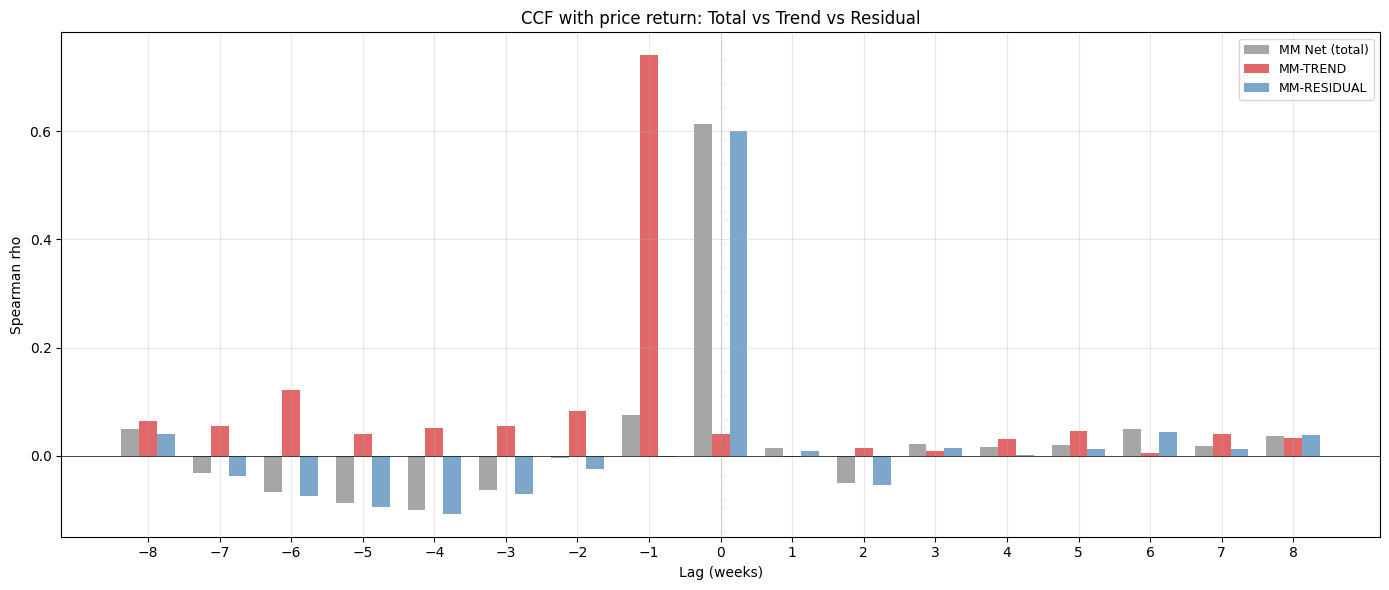

 Lag       Net     TREND     RESID
--------------------------------------
  -8    +0.050    +0.064    +0.041
  -7    -0.032    +0.056    -0.036
  -6    -0.067    +0.122    -0.074
  -5    -0.087    +0.040    -0.094
  -4    -0.100    +0.051    -0.107
  -3    -0.063    +0.056    -0.071
  -2    -0.003    +0.083    -0.024
  -1    +0.076    +0.740    -0.002
   0    +0.613    +0.040    +0.601
   1    +0.015    -0.001    +0.009
   2    -0.050    +0.015    -0.054
   3    +0.021    +0.009    +0.015
   4    +0.017    +0.032    +0.002
   5    +0.021    +0.047    +0.013
   6    +0.050    +0.006    +0.044
   7    +0.018    +0.041    +0.013
   8    +0.038    +0.033    +0.038


In [8]:
_, rhos_net, _ = compute_ccf(net_vals, price_vals, MAX_LAG)

fig, ax = plt.subplots(figsize=(14, 6))
w = 0.25
x_pos = np.array(lags)
ax.bar(x_pos - w, rhos_net, w, color='grey', alpha=0.7, label='MM Net (total)')
ax.bar(x_pos, rhos_trend, w, color='tab:red', alpha=0.7, label='MM-TREND')
ax.bar(x_pos + w, rhos_resid, w, color='steelblue', alpha=0.7, label='MM-RESIDUAL')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_xlabel('Lag (weeks)')
ax.set_ylabel('Spearman rho')
ax.set_title('CCF with price return: WTI Total vs Trend vs Residual')
ax.set_xticks(lags)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"Net":>8s}  {"TREND":>8s}  {"RESID":>8s}')
print('-' * 38)
for k, rn, rt, rr in zip(lags, rhos_net, rhos_trend, rhos_resid):
    print(f'{k:>4d}  {rn:>+8.3f}  {rt:>+8.3f}  {rr:>+8.3f}')

## 8. 5-year blocks

In [9]:
df['year'] = df['as_of_date'].dt.year

blocks_5y = [
    ('2010-2014', (2010, 2014)),
    ('2015-2019', (2015, 2019)),
    ('2020-2025', (2020, 2025)),
]
KEY = [-2, -1, 0, 1, 2]

for comp_label, comp_col in [('MM-TREND', 'mm_trend'), ('MM-RESIDUAL', 'mm_residual')]:
    print(f'\n=== {comp_label} vs price return ===')
    print(f'{"Block":>12s}  {"n":>4s}', end='')
    for k in KEY: print(f'  lag {k:+d}', end='')
    print()
    print('-' * (22 + 9 * len(KEY)))
    for label, (y_start, y_end) in blocks_5y + [('Full sample', (2010, 2025))]:
        sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
        c_vals = sub[comp_col].values
        p_vals = sub['price_ret'].values
        print(f'{label:>12s}  {len(sub):>4d}', end='')
        for k in KEY:
            if k >= 0:
                rho, _ = sp_stats.spearmanr(
                    c_vals[:len(c_vals)-k] if k > 0 else c_vals,
                    p_vals[k:] if k > 0 else p_vals)
            else:
                rho, _ = sp_stats.spearmanr(c_vals[-k:], p_vals[:len(p_vals)+k])
            print(f'  {rho:+.3f}', end='')
        print()


=== MM-TREND vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2014   208  +0.015  +0.893  -0.088  +0.023  +0.010
   2015-2019   261  +0.089  +0.944  +0.075  -0.061  -0.057
   2020-2025   292  +0.238  +0.482  +0.115  +0.109  +0.097
 Full sample   761  +0.083  +0.740  +0.040  -0.001  +0.015

=== MM-RESIDUAL vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2014   208  -0.002  -0.071  +0.746  -0.037  -0.064
   2015-2019   261  +0.039  +0.120  +0.601  +0.118  -0.069
   2020-2025   292  -0.081  -0.088  +0.551  -0.068  -0.030
 Full sample   761  -0.024  -0.002  +0.601  +0.009  -0.054


## 9. 3-year blocks

In [10]:
blocks_3y = [
    ('2010-2012', (2010, 2012)),
    ('2013-2015', (2013, 2015)),
    ('2016-2018', (2016, 2018)),
    ('2019-2021', (2019, 2021)),
    ('2022-2025', (2022, 2025)),
]

for comp_label, comp_col in [('MM-TREND', 'mm_trend'), ('MM-RESIDUAL', 'mm_residual')]:
    print(f'\n=== {comp_label} vs price return ===')
    print(f'{"Block":>12s}  {"n":>4s}', end='')
    for k in KEY: print(f'  lag {k:+d}', end='')
    print()
    print('-' * (22 + 9 * len(KEY)))
    for label, (y_start, y_end) in blocks_3y + [('Full sample', (2010, 2025))]:
        sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
        c_vals = sub[comp_col].values
        p_vals = sub['price_ret'].values
        print(f'{label:>12s}  {len(sub):>4d}', end='')
        for k in KEY:
            if k >= 0:
                rho, _ = sp_stats.spearmanr(
                    c_vals[:len(c_vals)-k] if k > 0 else c_vals,
                    p_vals[k:] if k > 0 else p_vals)
            else:
                rho, _ = sp_stats.spearmanr(c_vals[-k:], p_vals[:len(p_vals)+k])
            print(f'  {rho:+.3f}', end='')
        print()


=== MM-TREND vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2012   104  -0.087  +0.911  -0.215  +0.015  -0.088
   2013-2015   156  +0.082  +0.937  +0.010  +0.119  +0.164
   2016-2018   157  +0.163  +0.945  +0.127  -0.148  -0.058
   2019-2021   156  +0.102  +0.679  +0.094  +0.068  -0.048
   2022-2025   188  +0.152  +0.452  -0.102  -0.065  -0.024
 Full sample   761  +0.083  +0.740  +0.040  -0.001  +0.015

=== MM-RESIDUAL vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2012   104  +0.005  -0.161  +0.805  -0.143  -0.018
   2013-2015   156  +0.034  -0.022  +0.572  +0.078  +0.014
   2016-2018   157  -0.031  +0.170  +0.653  +0.167  -0.172
   2019-2021   156  -0.088  -0.075  +0.377  -0.118  -0.021
   2022-2025   188  -0.053  -0.019  +0.702  -0.015  -0.064
 Full sample   761  -0.024

## 10. 2-year blocks

In [11]:
blocks_2y = [
    ('2010-2011', (2010, 2011)),
    ('2012-2013', (2012, 2013)),
    ('2014-2015', (2014, 2015)),
    ('2016-2017', (2016, 2017)),
    ('2018-2019', (2018, 2019)),
    ('2020-2021', (2020, 2021)),
    ('2022-2023', (2022, 2023)),
    ('2024-2025', (2024, 2025)),
]

for comp_label, comp_col in [('MM-TREND', 'mm_trend'), ('MM-RESIDUAL', 'mm_residual')]:
    print(f'\n=== {comp_label} vs price return ===')
    print(f'{"Block":>12s}  {"n":>4s}', end='')
    for k in KEY: print(f'  lag {k:+d}', end='')
    print()
    print('-' * (22 + 9 * len(KEY)))
    for label, (y_start, y_end) in blocks_2y + [('Full sample', (2010, 2025))]:
        sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
        c_vals = sub[comp_col].values
        p_vals = sub['price_ret'].values
        print(f'{label:>12s}  {len(sub):>4d}', end='')
        for k in KEY:
            if k >= 0:
                rho, _ = sp_stats.spearmanr(
                    c_vals[:len(c_vals)-k] if k > 0 else c_vals,
                    p_vals[k:] if k > 0 else p_vals)
            else:
                rho, _ = sp_stats.spearmanr(c_vals[-k:], p_vals[:len(p_vals)+k])
            print(f'  {rho:+.3f}', end='')
        print()


=== MM-TREND vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2011    52  -0.109  +0.926  -0.232  -0.044  -0.103
   2012-2013   104  +0.011  +0.851  -0.099  +0.027  -0.025
   2014-2015   104  +0.049  +0.951  -0.003  +0.210  +0.183
   2016-2017   104  +0.098  +0.935  +0.099  -0.158  -0.089
   2018-2019   105  +0.101  +0.996  +0.094  -0.071  -0.119
   2020-2021   104  +0.163  +0.652  +0.134  +0.132  -0.027
   2022-2023   104  +0.284  +0.554  +0.004  -0.006  +0.034
   2024-2025    84  +0.018  +0.492  -0.259  -0.136  -0.046
 Full sample   761  +0.083  +0.740  +0.040  -0.001  +0.015

=== MM-RESIDUAL vs price return ===
       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2011    52  -0.008  -0.251  +0.869  -0.127  -0.088
   2012-2013   104  +0.068  +0.020  +0.717  -0.008  +0.026
   2014-2015   104  +0.029

## 11. Rolling 104-week correlation

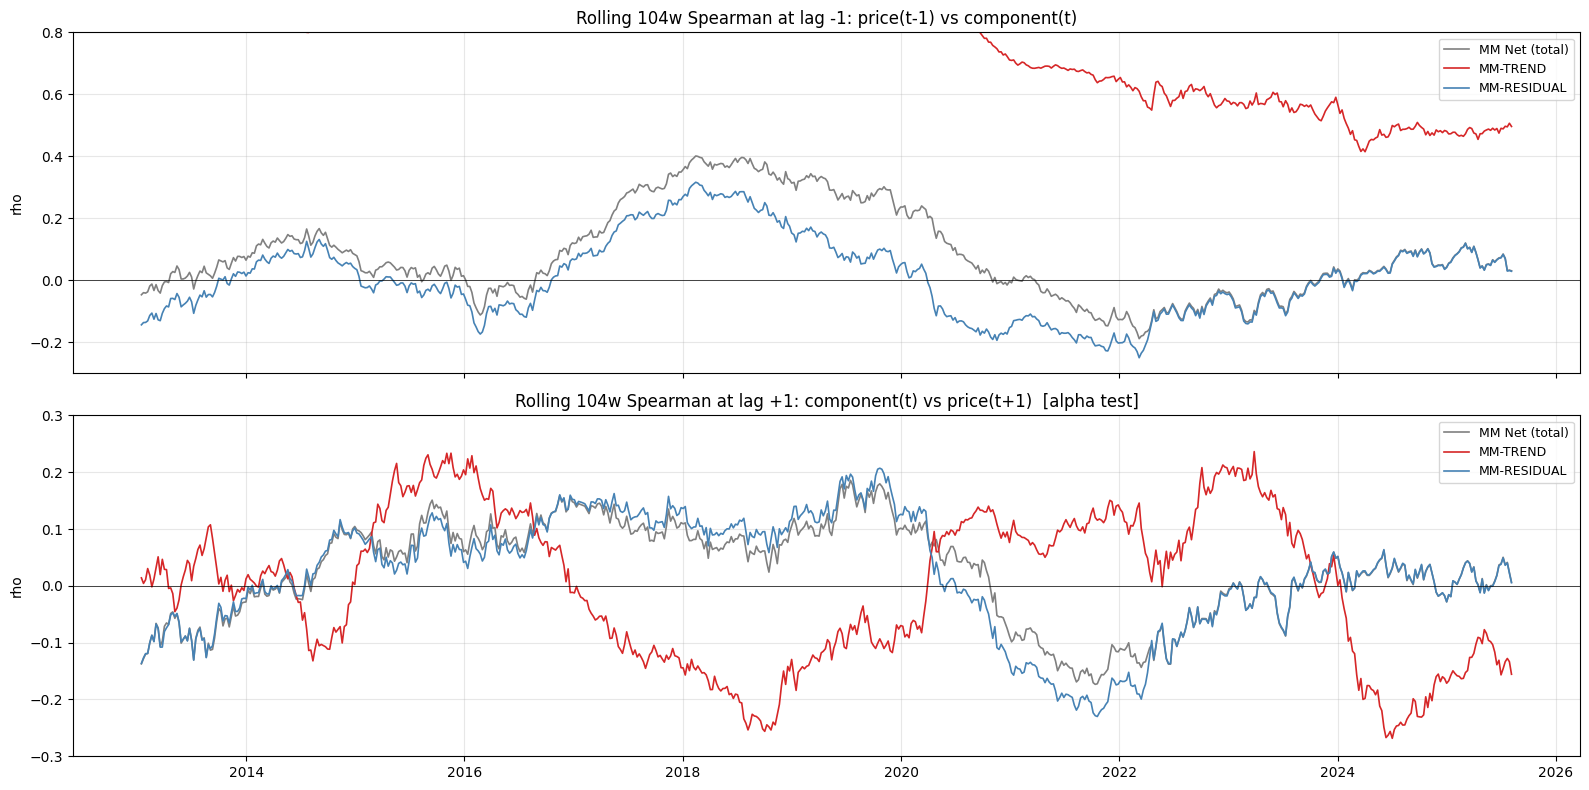

In [12]:
WINDOW = 104

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Lag -1: signal leads MM component
ax = axes[0]
for label, vals, color in [
    ('MM Net (total)', net_vals, 'grey'),
    ('MM-TREND',       trend_vals, 'tab:red'),
    ('MM-RESIDUAL',    resid_vals, 'steelblue'),
]:
    rhos = [
        sp_stats.spearmanr(vals[i-WINDOW:i], price_vals[i-WINDOW-1:i-1]).statistic
        if i >= WINDOW + 1 else float('nan')
        for i in range(len(vals))
    ]
    ax.plot(dt, rhos, label=label, color=color, lw=1.2)
ax.axhline(0, color='black', lw=0.5)
ax.set_title(f'Rolling {WINDOW}w Spearman at lag -1: WTI price(t-1) vs component(t)')
ax.set_ylabel('rho')
ax.set_ylim(-0.3, 0.8)
ax.legend(fontsize=9)

# Lag +1: component leads price (the alpha test)
ax = axes[1]
for label, vals, color in [
    ('MM Net (total)', net_vals, 'grey'),
    ('MM-TREND',       trend_vals, 'tab:red'),
    ('MM-RESIDUAL',    resid_vals, 'steelblue'),
]:
    rhos = [
        sp_stats.spearmanr(vals[i-WINDOW-1:i-1], price_vals[i-WINDOW:i]).statistic
        if i >= WINDOW + 1 else float('nan')
        for i in range(len(vals))
    ]
    ax.plot(dt, rhos, label=label, color=color, lw=1.2)
ax.axhline(0, color='black', lw=0.5)
ax.set_title(f'Rolling {WINDOW}w Spearman at lag +1: WTI component(t) vs price(t+1)  [alpha test]')
ax.set_ylabel('rho')
ax.set_ylim(-0.3, 0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 12. Cumulative P&L: MM-TREND vs MM-RESIDUAL

Compute the realised P&L of each component:

$$P\&L_t = \text{position}_{t-1} \times \Delta \text{price}_t$$

- **MM-TREND** P&L: the trend-following component (predicted from prior price)
- **MM-RESIDUAL** P&L: the non-trend-following component (everything else)

Since our decomposition is on *changes* (not levels), we cumulate the changes
to reconstruct position levels, then compute P&L from those levels.

In [13]:
# Reconstruct position levels from cumulative changes
df['mm_trend_level'] = df['mm_trend'].cumsum()
df['mm_residual_level'] = df['mm_residual'].cumsum()

# Weekly price change
df['price_chg'] = df['F1_RolledPrice'].diff()

# P&L: position(t-1) * price_change(t), raw contracts
df['pnl_total']    = df['mm_net'].shift(1) * df['price_chg']
df['pnl_trend']    = df['mm_trend_level'].shift(1) * df['price_chg']
df['pnl_residual'] = df['mm_residual_level'].shift(1) * df['price_chg']

pnl = df.dropna(subset=['pnl_total', 'pnl_trend', 'pnl_residual']).copy()

pnl['cum_total']    = pnl['pnl_total'].cumsum()
pnl['cum_trend']    = pnl['pnl_trend'].cumsum()
pnl['cum_residual'] = pnl['pnl_residual'].cumsum()

ann = np.sqrt(52)
for label, col in [('MM Total', 'pnl_total'),
                    ('MM-TREND', 'pnl_trend'),
                    ('MM-RESIDUAL', 'pnl_residual')]:
    sr = pnl[col].mean() / pnl[col].std() * ann
    total = pnl[col].sum()
    print(f'{label:14s}  cum P&L = ${total:>14,.0f}  Sharpe = {sr:+.2f}')


MM Total        cum P&L = $       785,761  Sharpe = +0.01
MM-TREND        cum P&L = $   -39,531,552  Sharpe = -0.32
MM-RESIDUAL     cum P&L = $    49,317,856  Sharpe = +0.40


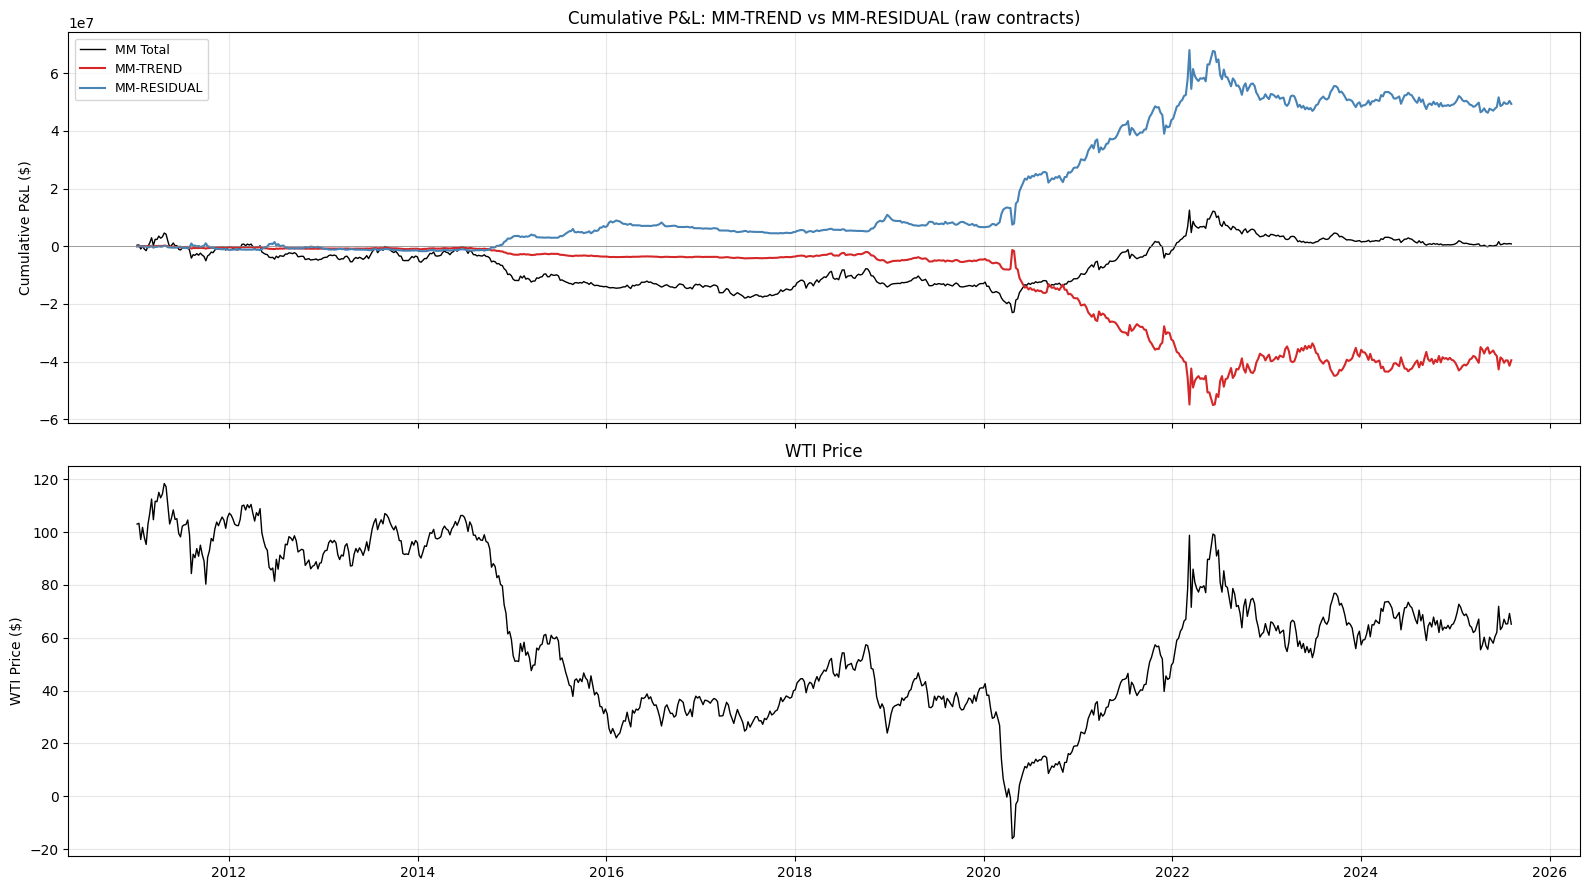

In [14]:
dt_pnl = pd.to_datetime(pnl['as_of_date'])

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

ax = axes[0]
ax.plot(dt_pnl, pnl['cum_total'], color='black', lw=1, label='MM Total')
ax.plot(dt_pnl, pnl['cum_trend'], color='tab:red', lw=1.5, label='MM-TREND')
ax.plot(dt_pnl, pnl['cum_residual'], color='steelblue', lw=1.5, label='MM-RESIDUAL')
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Cumulative P&L ($)')
ax.set_title('Cumulative P&L: WTI MM-TREND vs MM-RESIDUAL (raw contracts)')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(dt_pnl, pnl['F1_RolledPrice'], color='black', lw=1)
ax.set_ylabel('WTI Price ($)')
ax.set_title('WTI Price')

plt.tight_layout()
plt.show()


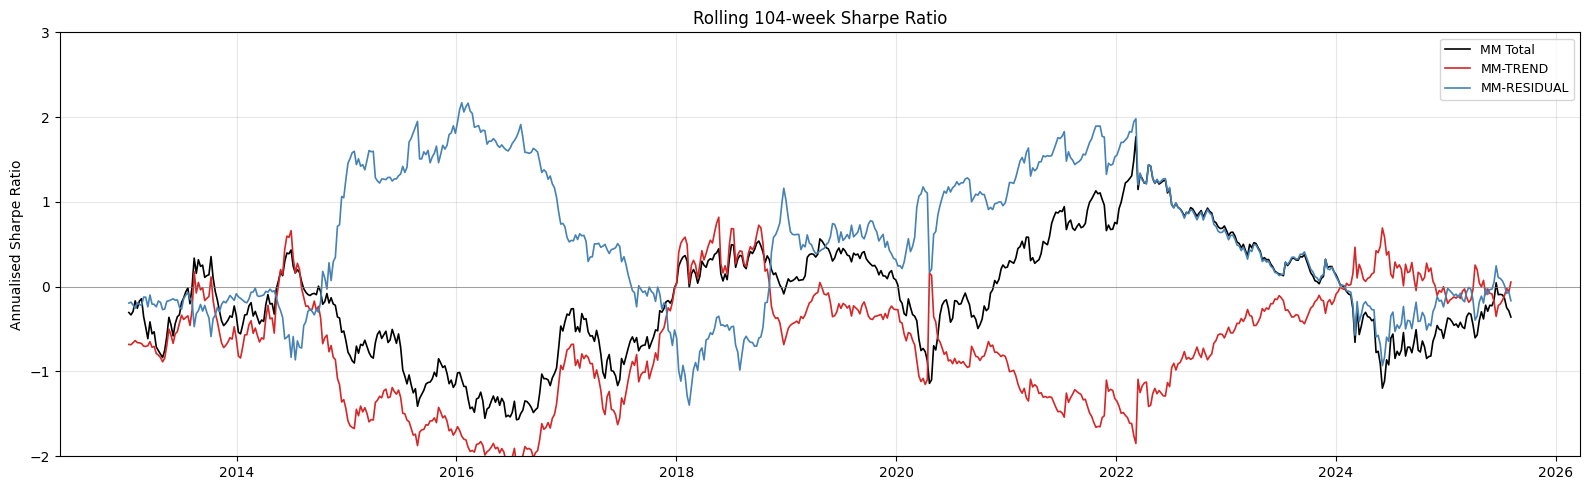

In [15]:
# Rolling 2-year Sharpe
ROLL_W = 104

fig, ax = plt.subplots(figsize=(16, 5))
for label, col, color in [('MM Total', 'pnl_total', 'black'),
                           ('MM-TREND', 'pnl_trend', 'tab:red'),
                           ('MM-RESIDUAL', 'pnl_residual', 'steelblue')]:
    roll_sr = pnl[col].rolling(ROLL_W).mean() / pnl[col].rolling(ROLL_W).std() * ann
    ax.plot(dt_pnl, roll_sr, color=color, lw=1.2, label=label)

ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Annualised Sharpe Ratio')
ax.set_title(f'Rolling {ROLL_W}-week Sharpe Ratio — WTI')
ax.set_ylim(-2, 3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
